In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
import warnings
warnings.filterwarnings("ignore")



In [16]:
df = pd.read_csv("cleaned_merged_heart_dataset.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


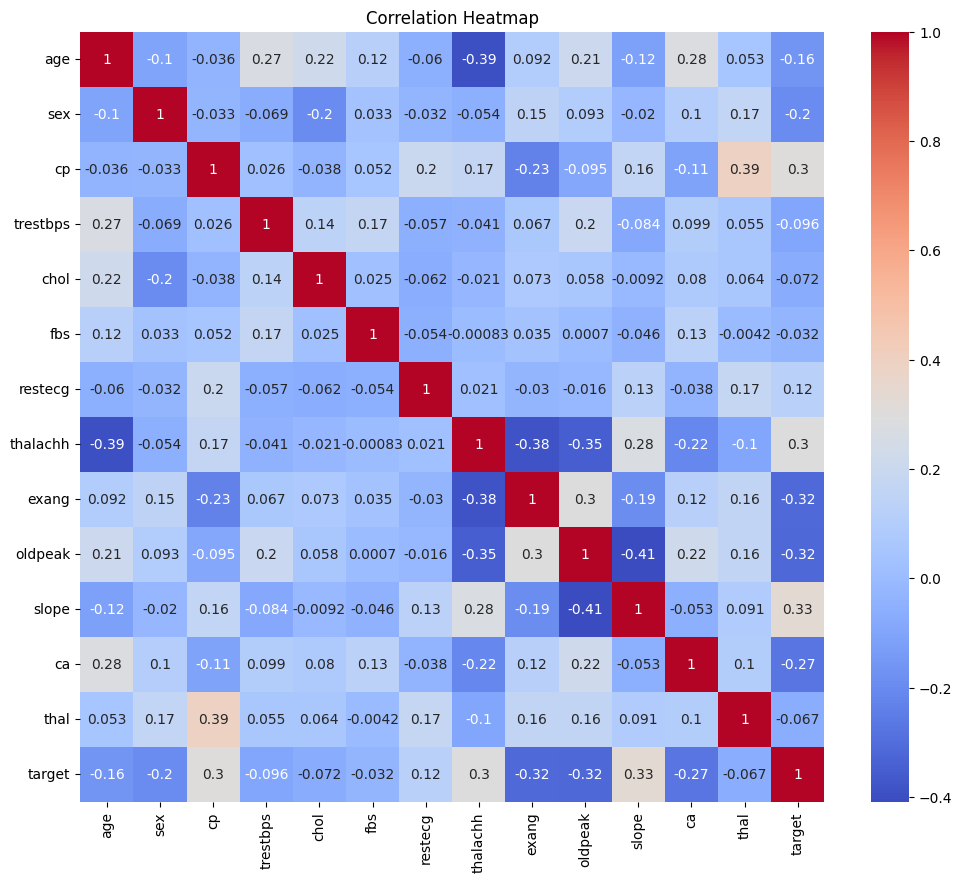

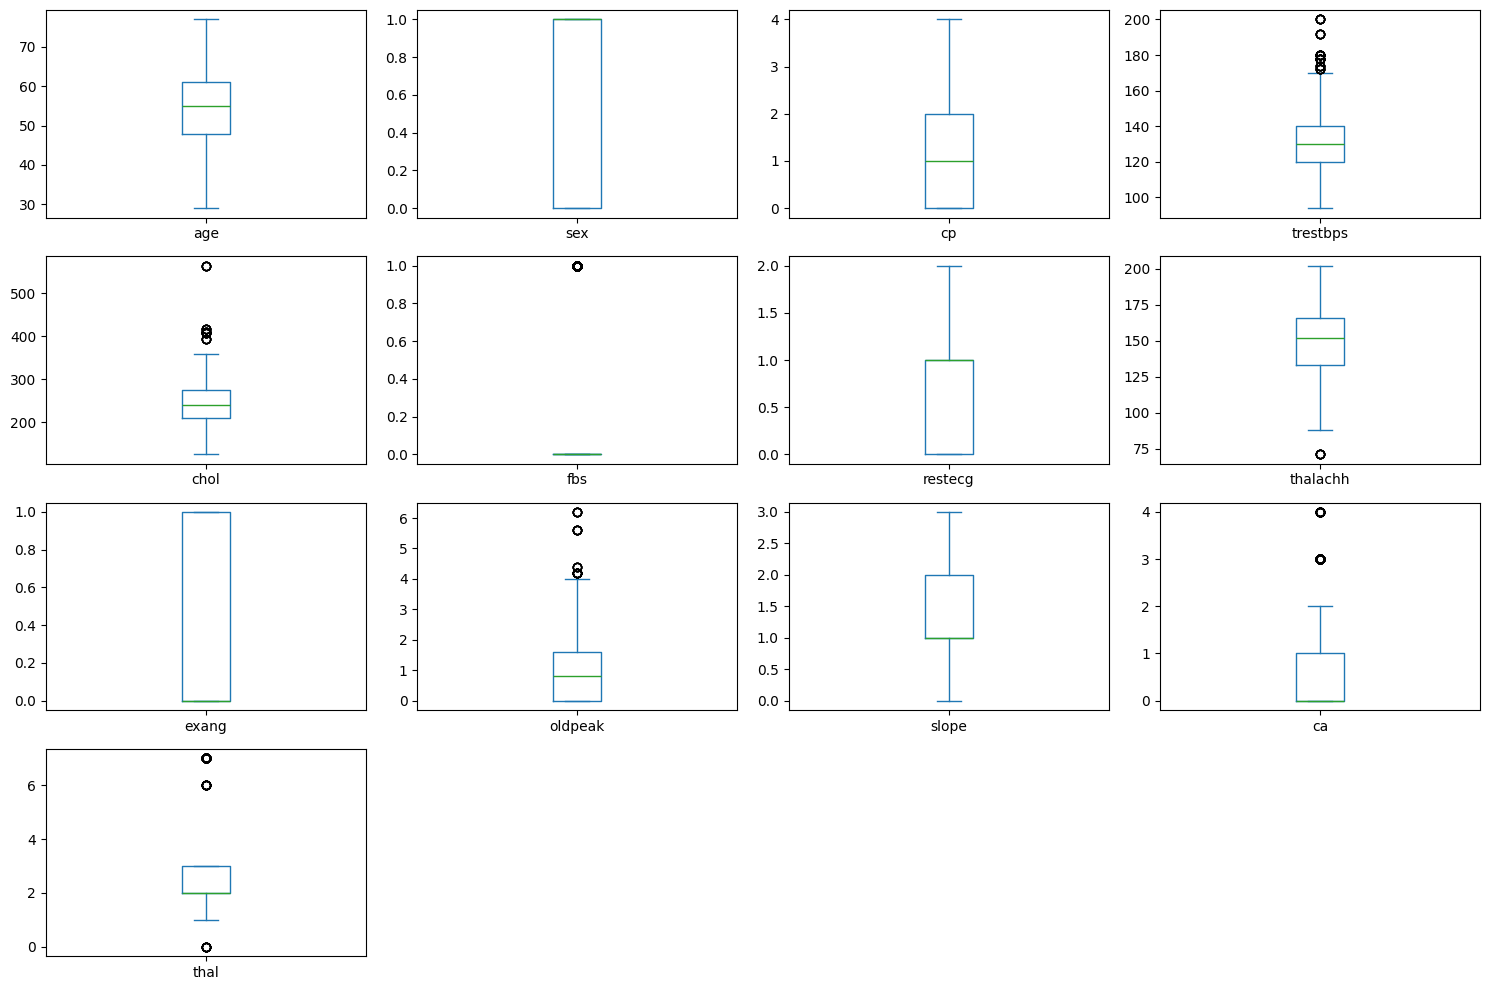

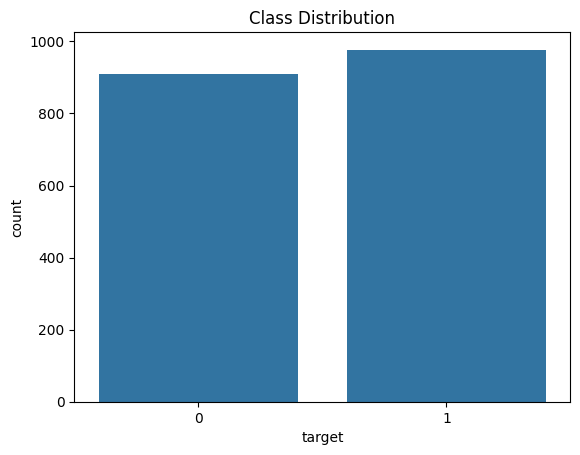

target
1    977
0    911
Name: count, dtype: int64


In [17]:
# ✅ Cell 4: Exploratory Data Analysis
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df.drop(columns=['target']).plot(kind='box', subplots=True, layout=(4,4), figsize=(15,10), sharex=False)
plt.tight_layout()
plt.show()

sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()
print(df['target'].value_counts())



In [18]:
# ✅ Cell 5: Preprocessing
le = LabelEncoder()
for col in ['sex', 'cp', 'restecg', 'slope', 'thal']:
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()
X = df.drop('target', axis=1)
y = df['target']
X_scaled = scaler.fit_transform(X)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)



In [19]:
# ✅ Cell 6: Improved AutoEncoder
input_dim = X_scaled.shape[1]
encoding_dim = 10

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu', activity_regularizer=regularizers.l1(1e-5))(encoded)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=32, shuffle=True, verbose=0)

encoder = Model(inputs=input_layer, outputs=encoded)
X_encoded = encoder.predict(X_scaled)



59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   


In [20]:
# ✅ Cell 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)


In [21]:
# ✅ Cell 8: TabNet Classifier
clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    momentum=0.3, lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1
)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_name=['test'],
    eval_metric=['accuracy'],
    max_epochs=200,
    patience=30,
    batch_size=128, virtual_batch_size=64
)


epoch 0  | loss: 0.86358 | test_accuracy: 0.53968 |  0:00:00s
epoch 1  | loss: 0.6447  | test_accuracy: 0.51852 |  0:00:00s
epoch 2  | loss: 0.59734 | test_accuracy: 0.53439 |  0:00:01s
epoch 3  | loss: 0.55066 | test_accuracy: 0.55291 |  0:00:01s
epoch 4  | loss: 0.55994 | test_accuracy: 0.50265 |  0:00:01s
epoch 5  | loss: 0.52602 | test_accuracy: 0.64021 |  0:00:02s
epoch 6  | loss: 0.50461 | test_accuracy: 0.55291 |  0:00:02s
epoch 7  | loss: 0.51573 | test_accuracy: 0.61905 |  0:00:02s
epoch 8  | loss: 0.49296 | test_accuracy: 0.60053 |  0:00:03s
epoch 9  | loss: 0.50185 | test_accuracy: 0.63492 |  0:00:03s
epoch 10 | loss: 0.50714 | test_accuracy: 0.6746  |  0:00:03s
epoch 11 | loss: 0.49718 | test_accuracy: 0.65873 |  0:00:04s
epoch 12 | loss: 0.50709 | test_accuracy: 0.73016 |  0:00:04s
epoch 13 | loss: 0.49694 | test_accuracy: 0.68254 |  0:00:04s
epoch 14 | loss: 0.48163 | test_accuracy: 0.73016 |  0:00:05s
epoch 15 | loss: 0.46999 | test_accuracy: 0.76455 |  0:00:05s
epoch 16

Confusion Matrix:
 [[162  20]
 [  2 194]]
Accuracy: 0.9418
Precision: 0.9065
Recall: 0.9898
F1 Score: 0.9463
Sensitivity: 0.9898
Specificity: 0.8901


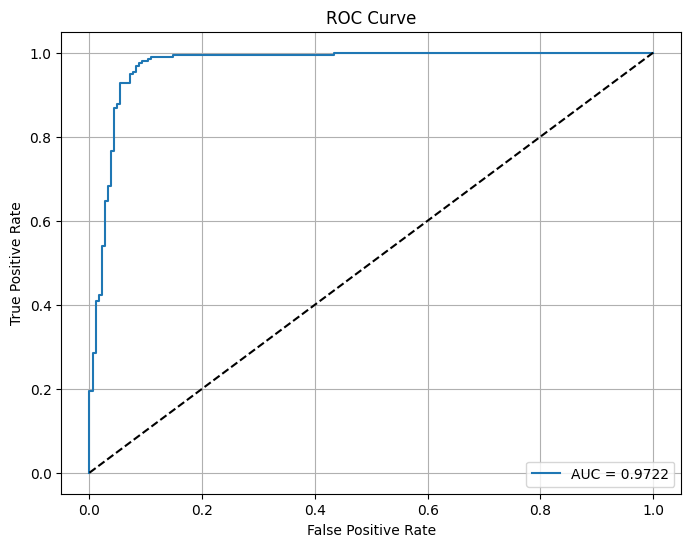

In [22]:
# ✅ Cell 9: Evaluation
y_pred = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
sens = tp / (tp + fn)

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Sensitivity: {sens:.4f}")
print(f"Specificity: {spec:.4f}")

# ✅ Cell 10: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


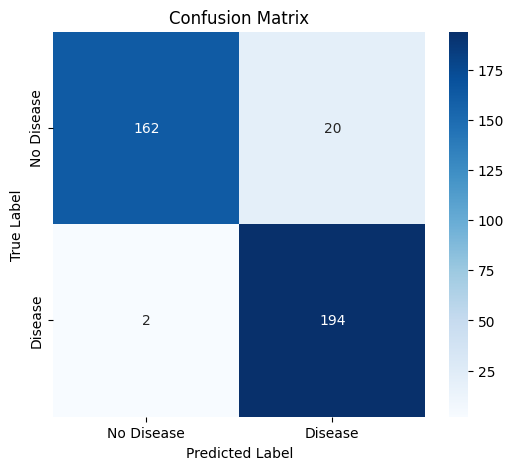

In [23]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
